# 01 - WSI to Tissue Sections

This notebook walks through the core pipeline: loading flat whole-slide images (WSI),
segmenting individual tissue sections, extracting them as tiles, and renaming with
global slice indices.

**Docker first-run path:** if `/data/input` is empty, this notebook generates two
synthetic PNG slides so you can run it immediately.

**Prerequisites:** Docker and the Conda environment already include the notebook
dependencies. For a local editable install, use `pip install -e ".[visualization]"`
from the `wsi-tissue-pipeline` root.

**Pipeline stages covered:**
1. Configure paths and segmentation parameters
2. Run `process_directory()` to segment + extract tiles
3. Quick visual check of output tiles
4. Rename files with global slice indices via `rename_outputs_by_overall_index()`

In [8]:
import shutil
from pathlib import Path

import matplotlib.pyplot as plt
from PIL import Image

from wsi_pipeline.demo_data import create_synthetic_wsi

from wsi_pipeline.config import PipelineConfig, SegmentationConfig, TileConfig, OutputConfig
from wsi_pipeline.wsi_processing import process_directory
from wsi_pipeline.tiles.naming import rename_outputs_by_overall_index


%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Step 1: Configure Paths and Parameters

Set the input WSI directory, file pattern, and output directory.  Then create a
`PipelineConfig` with segmentation parameters tuned for your data.

Key `SegmentationConfig` fields:
- **`backend`** - segmentation algorithm (`"local-entropy"`, `"otsu"`, etc.)
- **`target_long_side`** - thumbnail long-side in px for mask computation
- **`min_area_px`** - discard connected components smaller than this
- **`struct_elem_px`** - morphological closing disk radius; larger values smooth and connect nearby tissue
- **`split_touching`** / **`r_split`** - watershed split for fused sections. Increase `r_split` one step at a time (for example 3 to 4) if adjacent sections stay merged; decrease it (1-2) if one section fragments.
- **`keep_top_k`** - optional safety-net: keep only the K largest components after splitting when you know the expected section count.
- **`component_qc_enabled`** - score candidate sections for artifact-like shape/stain properties and surface likely artifacts in notebook 02 QC.
- **Tuning order** - raise `min_area_px` for fragments/background, tune `r_split` for touching sections, and lower `struct_elem_px` only if morphology visibly bridges nearby sections.

In [9]:
# Docker notebooks mount input data at /data and outputs at /output.
# # Replace these defaults if you want to point at a different dataset.
# subject_wsi_dir = Path("/data/input").expanduser().resolve()
# pattern = "*.png"  # Change this for your own inputs (for example, "*.jpg" or "*.tif")
# output_dir = Path("/output/tissue_sections").expanduser().resolve()

# dom's test
subject_wsi_dir = Path("/cis/home/dpadova/Documents/temporal_bone_project/data/FlatFiles").expanduser().resolve()
output_dir = Path("/cis/home/dpadova/Documents/temporal_bone_project/notebook_flatfile_smoke_level7/tissue_sections").expanduser().resolve()
pattern = "level_7_*.jpg"  # Change this for your own inputs (for example, "*.jpg" or "*.tif")


subject_wsi_dir.mkdir(parents=True, exist_ok=True)
known_inputs = sorted(
    p
    for glob_pattern in ("*.png", "*.jpg", "*.jpeg", "*.tif", "*.tiff", "*.bmp", "*.vsi", "*.ets")
    for p in subject_wsi_dir.glob(glob_pattern)
)

if not known_inputs:
    print("No inputs found in /data/input. Generating demo PNG slides...")
    create_synthetic_wsi(subject_wsi_dir / "synthetic_wsi_001.png", seed=101)
    create_synthetic_wsi(subject_wsi_dir / "synthetic_wsi_002.png", seed=202)
    known_inputs = sorted(subject_wsi_dir.glob("*.png"))
else:
    suffixes = sorted({p.suffix.lower() for p in known_inputs})
    print(f"Found existing inputs in {subject_wsi_dir} with suffixes: {suffixes}")
    print("Update `pattern` below if you want to target a different file type.")

# --- Pipeline configuration ---
config = PipelineConfig(
    segmentation=SegmentationConfig(
        backend="local-entropy",
        target_long_side=1800,
        min_area_px=3000,#12000,
        struct_elem_px=5,#7,#4,
        split_touching=True, #False,#True,
        r_split=5,#3, #2,#3,
        stain_gate=True,
        stain_gate_mode="adaptive-he",  # "adaptive-he", "adaptive-od", or "fixed-saturation"
        stain_min_od=0.10,
        stain_min_he_signal=0.0,
        stain_od_bg_percentile=0.80,
        stain_od_mad_multiplier=4.0,
        stain_min_saturation=0.08, # 0.0005, # 0.0005 was good for adaptive-od, #0.10, #0.12,
        stain_pre_open_px=0,
        keep_top_k=None,#4,  # level 07 safety-net; use None if section counts vary too much
        appendage_refinement_enabled=True,
        appendage_refinement_mode="trim",
        appendage_refinement_profile="he_sections",
        component_qc_enabled=True,
        component_qc_mode="annotate",
        component_qc_profile="he_sections",
        diagnostics=True,
    ),
    tiles=TileConfig(
        chunk_size=512,
        pad_multiple=512,
        extra_margin_px=0,
    ),
    output=OutputConfig(
        format="tiff",
        convert_to_uint8=False,
    ),
    specimen_spacing=9,  # e.g., macaque: every 10th slice collected
)

print(f"Input dir:  {subject_wsi_dir}")
print(f"Pattern:    {pattern}")
print(f"Output dir: {output_dir}")
print(config.model_dump_json(indent=2))

Found existing inputs in /cis/home/dpadova/Documents/temporal_bone_project/data/FlatFiles with suffixes: ['.jpg']
Update `pattern` below if you want to target a different file type.
Input dir:  /cis/home/dpadova/Documents/temporal_bone_project/data/FlatFiles
Pattern:    level_7_*.jpg
Output dir: /cis/home/dpadova/Documents/temporal_bone_project/notebook_flatfile_smoke_level7/tissue_sections
{
  "segmentation": {
    "backend": "local-entropy",
    "target_long_side": 1800,
    "min_area_px": 3000,
    "struct_elem_px": 5,
    "stain_gate": true,
    "stain_gate_mode": "adaptive-he",
    "stain_min_saturation": 0.08,
    "stain_min_od": 0.1,
    "stain_min_he_signal": 0.0,
    "stain_od_bg_percentile": 0.8,
    "stain_od_mad_multiplier": 4.0,
    "stain_pre_open_px": 0,
    "split_touching": true,
    "r_split": 5,
    "keep_top_k": null,
    "appendage_refinement_enabled": true,
    "appendage_refinement_mode": "trim",
    "appendage_refinement_profile": "he_sections",
    "component_q

## Step 2: Process the WSI Directory

`process_directory()` iterates over all files matching `pattern`, segments tissue
regions, extracts individual tiles, and writes them to `output_dir`.

In [10]:
# Clean output directory for a fresh run
if output_dir.exists():
    shutil.rmtree(output_dir)
output_dir.mkdir(parents=True, exist_ok=True)

# Run the processing pipeline
results = process_directory(
    subject_wsi_dir,
    output_dir,
    pattern=pattern,
    config=config,
)

# Summary
total_tiles = sum(len(v) for v in results.values())
print(f"\nProcessed {len(results)} WSI files -> {total_tiles} tissue tiles")

/cis/home/dpadova/Documents/git/wsi-tissue-pipeline/src/wsi_pipeline/wsi_processing.py:161: FutureWarning: `binary_closing` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.closing` instead.
  bw = morphology.binary_closing(bw, footprint=fp)
/cis/home/dpadova/Documents/git/wsi-tissue-pipeline/src/wsi_pipeline/wsi_processing.py:163: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  bw = morphology.remove_small_objects(bw, min_size=min_area)
/cis/home/dpadova/Documents/git/wsi-tissue-pipeline/src/wsi_pipeline/wsi_processing.py:164: FutureWarning: Parameter `area_threshold` is deprecated since version 0.26.0 and


Processed 15 WSI files -> 47 tissue tiles


In [11]:
# List output tiles
tiles = sorted(output_dir.glob("*.tif"))
print(f"{len(tiles)} output tiles")
for t in tiles[:10]:
    print(f"  {t.name}")
if len(tiles) > 10:
    print(f"  ... and {len(tiles) - 10} more")

47 output tiles
  level_7_Image_00_00.tif
  level_7_Image_00_01.tif
  level_7_Image_00_02.tif
  level_7_Image_00_03.tif
  level_7_Image_01_00.tif
  level_7_Image_01_01.tif
  level_7_Image_01_02.tif
  level_7_Image_02_00.tif
  level_7_Image_02_01.tif
  level_7_Image_02_02.tif
  ... and 37 more


In [ ]:
# Check slide 12 metadata
import json
from pathlib import Path

p = output_dir / "level_7_Image_12_metadata.json"
m = json.loads(p.read_text())

print(m["n_tiles"])
print(m["segmentation"]["n_components"])
print(m["appendage_refinement"])

3
3
{'enabled': True, 'mode': 'trim', 'profile': 'he_sections', 'n_appendages_flagged': 74, 'flagged_area_px': 3182, 'n_appendages_trimmed': 74, 'trimmed_area_px': 3182, 'trimmed_fraction': 0.004591219833146241, 'appendage_reason': 'peripheral_low_he_appendage;peripheral_low_he_strip', 'records': [{'component_label': 1, 'appendage_label': 1, 'area_px': 1, 'area_fraction': 5.055586169938473e-06, 'bbox_y0': 1, 'bbox_x0': 1232, 'bbox_y1': 2, 'bbox_x1': 1233, 'aspect_ratio': 1.0, 'extent': 1.0, 'mean_he_signal': 0.0, 'he_threshold': 0.0, 'boundary_contact_fraction': 0.0, 'trimmed': False, 'appendage_reason': ''}, {'component_label': 1, 'appendage_label': 2, 'area_px': 1, 'area_fraction': 5.055586169938473e-06, 'bbox_y0': 2, 'bbox_x0': 1234, 'bbox_y1': 3, 'bbox_x1': 1235, 'aspect_ratio': 1.0, 'extent': 1.0, 'mean_he_signal': 0.0009346761611042632, 'he_threshold': 0.0, 'boundary_contact_fraction': 0.0, 'trimmed': False, 'appendage_reason': ''}, {'component_label': 1, 'appendage_label': 3, 'a

## Step 3: Quick Visual Check

Display a few sample tiles to verify segmentation quality.  For a comprehensive
QC review with contact sheets, see **notebook 02**.

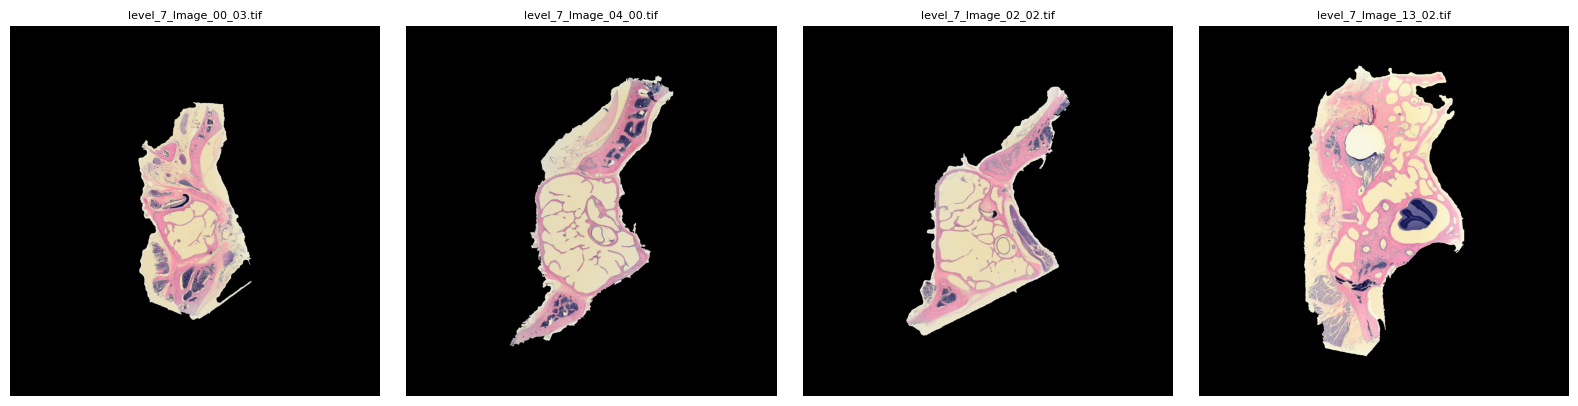

In [12]:
import random

sample = random.sample(tiles, min(4, len(tiles)))
fig, axes = plt.subplots(1, len(sample), figsize=(4 * len(sample), 4))
if len(sample) == 1:
    axes = [axes]
for ax, path in zip(axes, sample):
    ax.imshow(Image.open(path))
    ax.set_title(path.name, fontsize=8)
    ax.axis("off")
plt.tight_layout()
plt.show()

## Step 4: Rename Files with Global Indices

`rename_outputs_by_overall_index()` assigns a `_ZZZZ` suffix to each tile using
the arithmetic progression `start + rank * (spacing + 1)`.  For the macaque
dataset with every 10th slice collected, `spacing=9` produces indices
`0001, 0011, 0021, ...` 

In [13]:
renames = rename_outputs_by_overall_index(
    output_dir,
    pattern=pattern,
    spacing=9,
    pad=4,
    start=1,
    dry_run=False,
)

print(f"Renamed {len(renames)} files")
for old, new in renames[:5]:
    print(f"  {old.name} -> {new.name}")
if len(renames) > 5:
    print("  ...")
    for old, new in renames[-3:]:
        print(f"  {old.name} -> {new.name}")

manifest_path = output_dir / "tile_manifest.json"
if manifest_path.exists():
    print(f"\nWrote QC manifest: {manifest_path}")

Renamed 47 files
  level_7_Image_00_00.tif -> level_7_Image_00_00_0001.tif
  level_7_Image_00_01.tif -> level_7_Image_00_01_0011.tif
  level_7_Image_00_02.tif -> level_7_Image_00_02_0021.tif
  level_7_Image_00_03.tif -> level_7_Image_00_03_0031.tif
  level_7_Image_01_00.tif -> level_7_Image_01_00_0041.tif
  ...
  level_7_Image_14_00.tif -> level_7_Image_14_00_0441.tif
  level_7_Image_14_01.tif -> level_7_Image_14_01_0451.tif
  level_7_Image_14_02.tif -> level_7_Image_14_02_0461.tif

Wrote QC manifest: /cis/home/dpadova/Documents/temporal_bone_project/notebook_flatfile_smoke_level7/tissue_sections/tile_manifest.json


## Step 5 (Optional): Process Additional Pyramid Levels

Different pyramid levels may need different segmentation parameters.  Uncomment
and adjust the cell below for a second level.

In [14]:
# # --- Level 06 example ---
# subject_wsi_dir_06 = Path(
#     "/data/input_level06"  # Replace with your level 06 flat files
# ).expanduser().resolve()
# pattern_06 = "*.jpg"
# output_dir_06 = Path(
#     "/output/tissue_sections_level06"  # Replace with your level 06 output directory
# ).expanduser().resolve()
#
# config_06 = PipelineConfig(
#     segmentation=SegmentationConfig(
#         backend="local-entropy",
#         target_long_side=2048,
#         min_area_px=20000,
#         struct_elem_px=7,
#         split_touching=True,
#         r_split=3,
#         keep_top_k=3,
#         diagnostics=True,
#     ),
#     tiles=TileConfig(chunk_size=512, pad_multiple=512, extra_margin_px=0),
#     output=OutputConfig(format="tiff", convert_to_uint8=False),
#     specimen_spacing=9,
# )
#
# if output_dir_06.exists():
#     shutil.rmtree(output_dir_06)
# output_dir_06.mkdir(parents=True, exist_ok=True)
#
# results_06 = process_directory(
#     subject_wsi_dir_06, output_dir_06, pattern=pattern_06, config=config_06
# )

## Next Steps

- **Notebook 02** - Generate full QC contact sheets to identify artifacts
- **Notebook 03** - Visualize extracted tissues in Neuroglancer
- **Notebook 04** - Prepare the image stack for EM-LDDMM registration